In [29]:
# Cell 1 — setup
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import torch
from src.data_loader import fetch_data, compute_features
from sklearn.preprocessing import StandardScaler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
# Cell 2 — reload and reprocess data exactly as in notebook 2
# We redo this so the notebook is self-contained
prices = fetch_data()
features = compute_features(prices)

lower = np.percentile(features.values, 1, axis=0)
upper = np.percentile(features.values, 99, axis=0)
clipped = np.clip(features.values, lower, upper)

scaler = StandardScaler()
X = scaler.fit_transform(clipped)

print(f"Features shape: {X.shape}")

[*********************100%***********************]  4 of 4 completed

Features shape: (3753, 16)


In [31]:
# Cell 3 — load the regime labels you saved in notebook 2
regime_df = pd.read_csv("../data/processed/regime_labels.csv",
                         index_col="date", parse_dates=True)

# Align the regime labels with the features index
# (they should match, but we make sure explicitly)
aligned = regime_df.reindex(features.index).dropna()
regime_labels = aligned["regime"].values.astype(int)

print(f"Regime labels shape: {regime_labels.shape}")
print(f"Feature rows: {X.shape[0]}")
# These two numbers must match

Regime labels shape: (3753,)
Feature rows: 3753


In [32]:
# Cell 4 — create the prediction target: next day's SPY return
# The KAN will look at today's features and try to predict
# whether SPY goes up or down tomorrow.
# We shift by -1 so that row i contains tomorrow's return.

spy_returns = prices["SPY"].pct_change().shift(-1)
spy_returns = spy_returns.loc[features.index]
spy_returns = spy_returns.reindex(aligned.index).dropna()

# Trim everything to the same length
# (the shift(-1) removes the last row since there's no "tomorrow" for it)
min_len = min(len(spy_returns), len(regime_labels), X.shape[0])
X_aligned        = X[:min_len]
regime_aligned   = regime_labels[:min_len]
y_aligned        = spy_returns.values[:min_len]

print(f"Final aligned shape: {X_aligned.shape}")
print(f"Target (y) shape: {y_aligned.shape}")
print(f"Sample target values: {y_aligned[:5].round(4)}")
# Should see small numbers like 0.0043, -0.0021 etc. (daily % returns)

Final aligned shape: (3752, 16)
Target (y) shape: (3752,)
Sample target values: [-0.005  -0.0309  0.0021 -0.0072  0.0126]


In [33]:
# Cell 5 — train one KAN per regime
# This is the core of the project.
# For each regime we:
#   1. Filter the data to only days in that regime
#   2. Train a KAN to predict next-day SPY return from features
#   3. Save the trained KAN

from kan import KAN

N_REGIMES = 3
input_dim = X_aligned.shape[1]
kan_models = {}

for regime in range(N_REGIMES):
    print(f"\n--- Training KAN for Regime {regime} ---")
    
    # Filter to only days labeled as this regime
    mask = regime_aligned == regime
    X_regime = torch.tensor(X_aligned[mask], dtype=torch.float32)
    y_regime = torch.tensor(y_aligned[mask], dtype=torch.float32).unsqueeze(1)
    
    print(f"  Training samples: {X_regime.shape[0]} days")
    
    # Build the KAN
    # Architecture: input_dim features -> 4 hidden nodes -> 1 output (return)
    # Keeping the hidden layer small forces the model to be selective
    model = KAN(width=[input_dim, 4, 1], grid=5, k=3, seed=42, save_act=True)
    model.speed()  # disables symbolic branch, much faster on CPU
    
    # Package data the way pykan expects it
    dataset = {
        "train_input": X_regime,
        "train_label": y_regime,
        "test_input":  X_regime,   # using same for now, we'll do proper splits in backtest
        "test_label":  y_regime
    }
    
    # Train — LBFGS is the optimizer pykan recommends for small networks
    # lamb is L1 regularization — encourages sparse, interpretable connections
    model.fit(dataset, opt="LBFGS", steps=50, lamb=0.01, log=50)
    
    kan_models[regime] = model
    print(f"  Done.")

print("\nAll regimes trained.")


--- Training KAN for Regime 0 ---
  Training samples: 810 days
checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 1.68e-02 | test_loss: 1.68e-02 | reg: 0.00e+00 | : 100%|█| 50/50 [00:03<00:00, 15.38it


  Done.

--- Training KAN for Regime 1 ---
  Training samples: 1168 days
checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 9.63e-03 | test_loss: 9.63e-03 | reg: 0.00e+00 | : 100%|█| 50/50 [00:04<00:00, 10.47it


  Done.

--- Training KAN for Regime 2 ---
  Training samples: 1774 days
checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 6.52e-03 | test_loss: 6.52e-03 | reg: 0.00e+00 | : 100%|█| 50/50 [00:06<00:00,  8.31it

  Done.

All regimes trained.


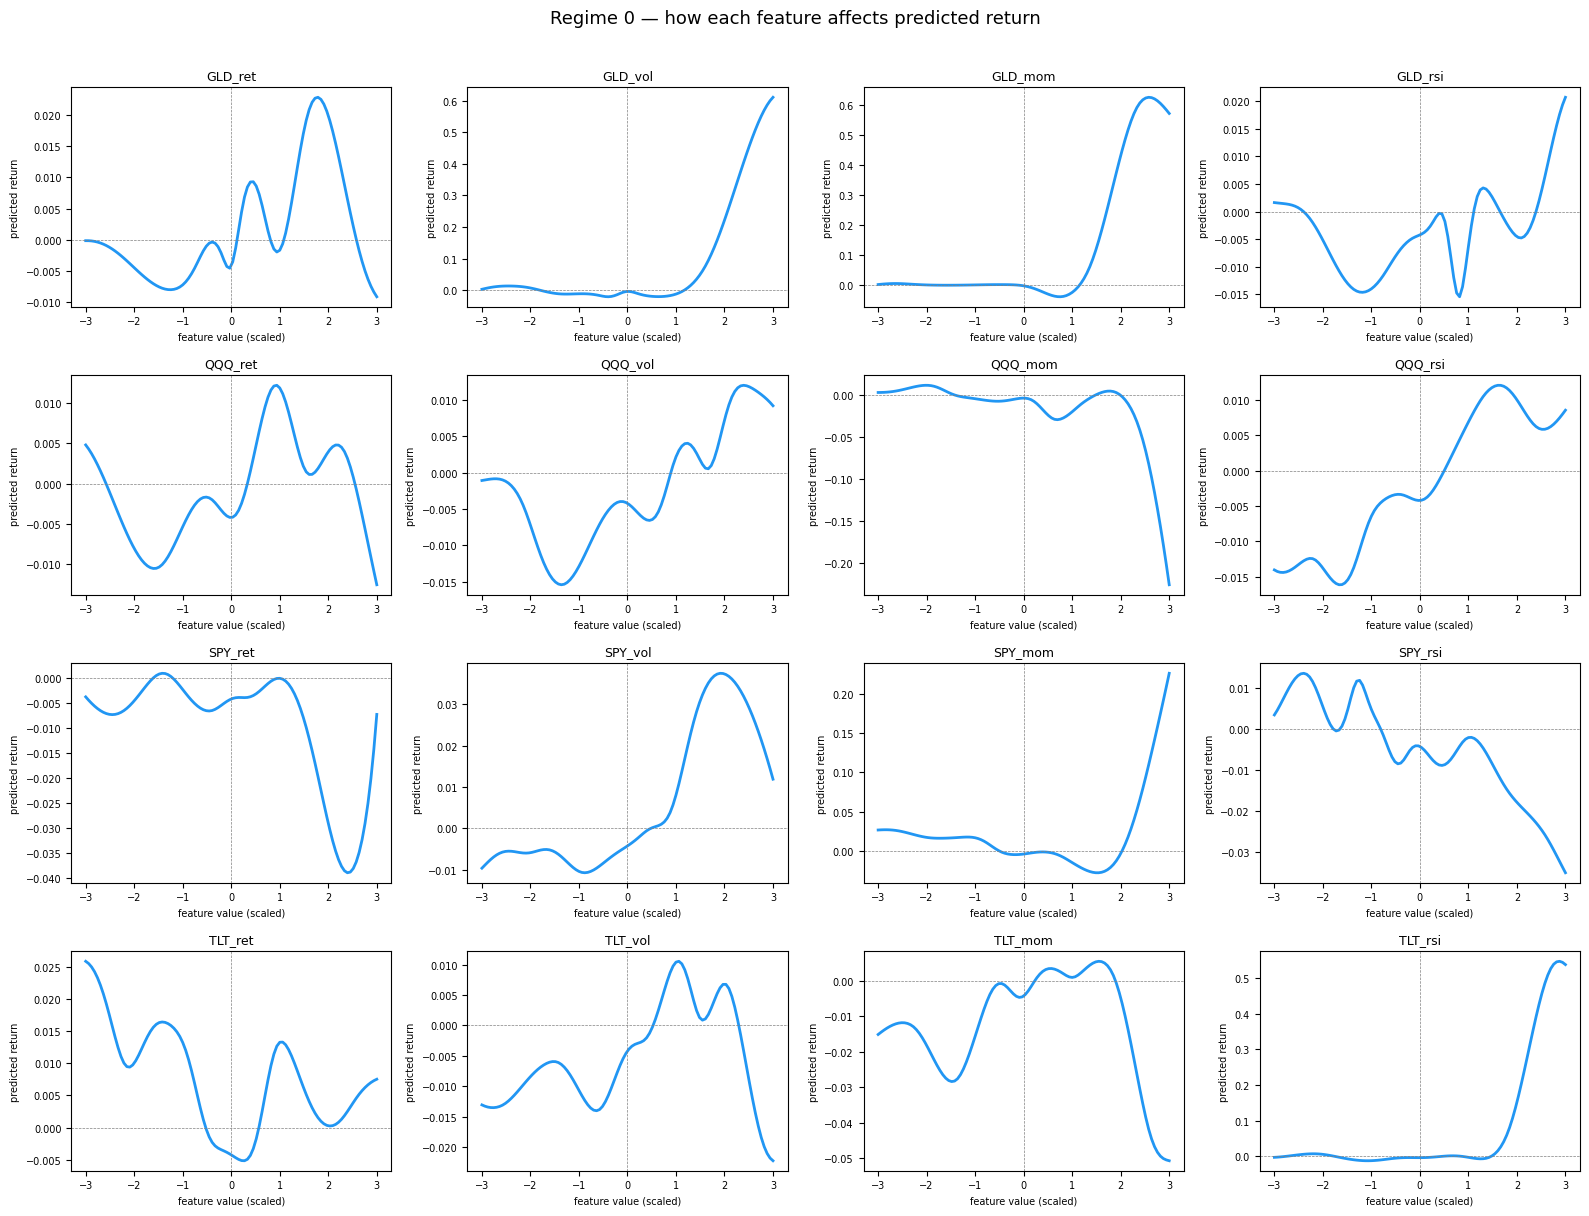

Saved regime 0 plot.


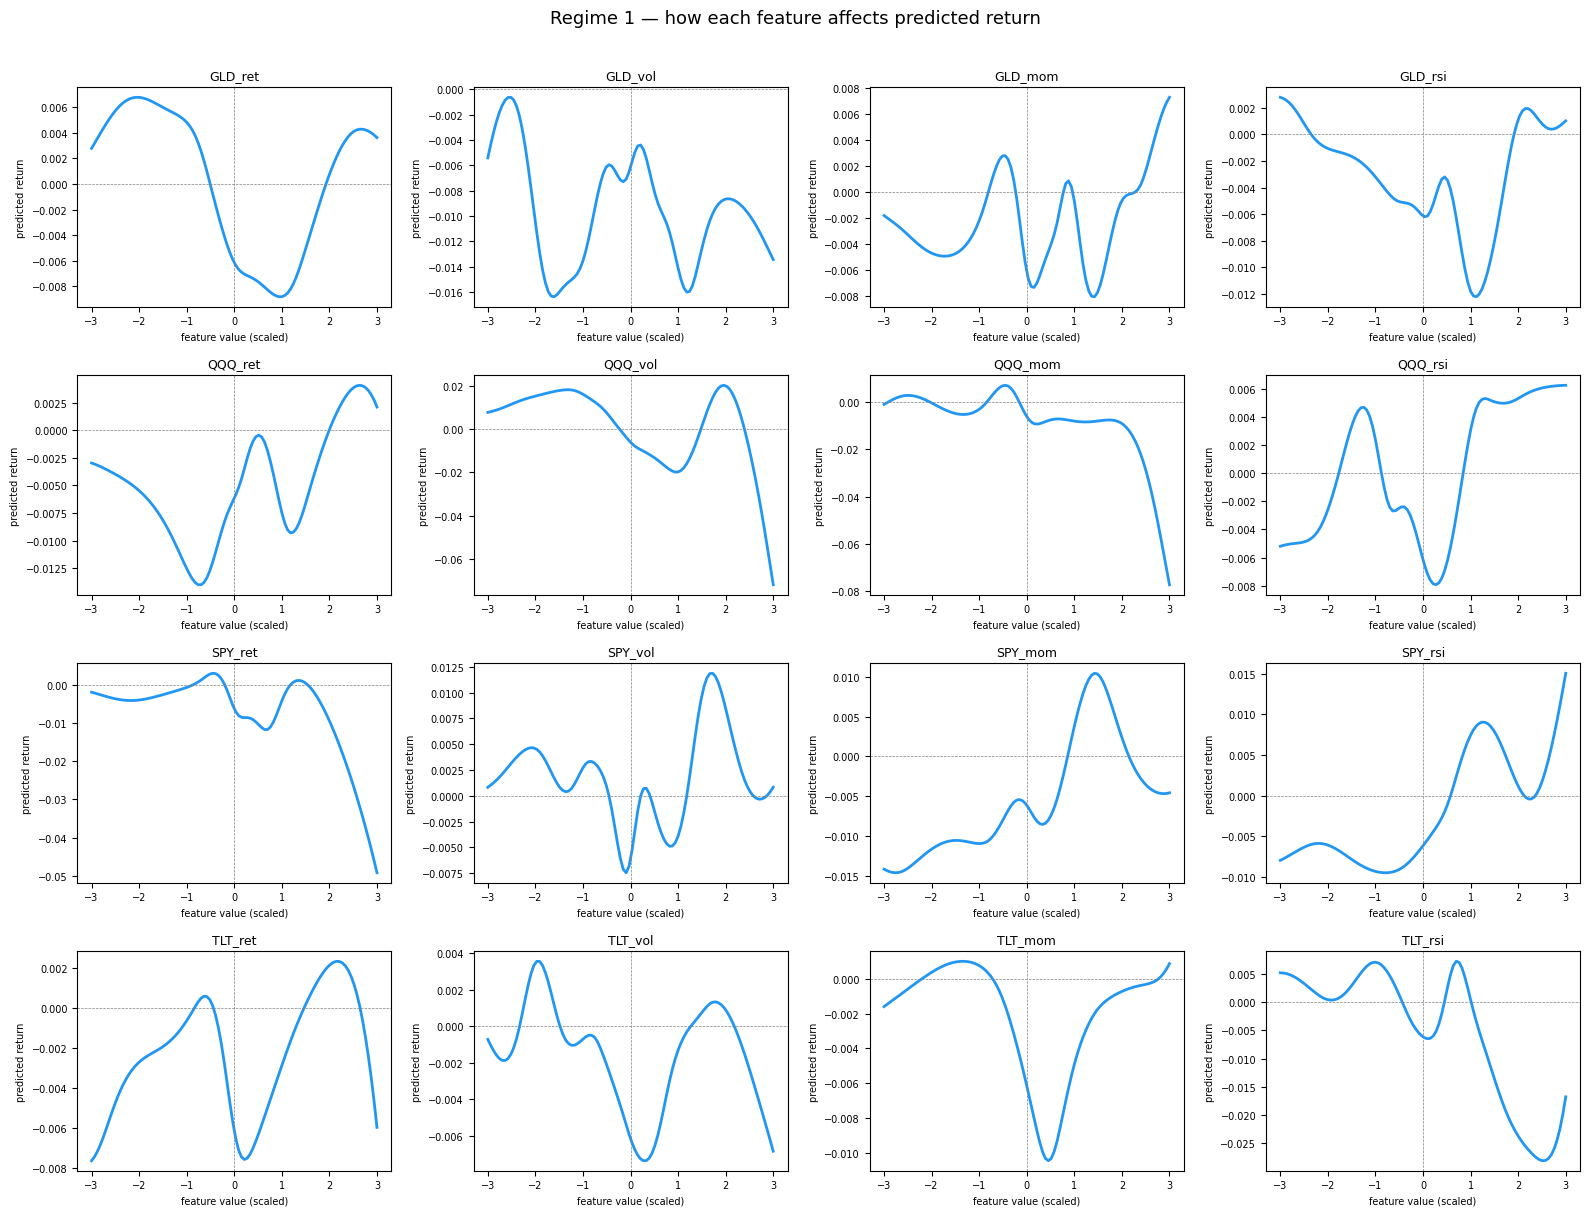

Saved regime 1 plot.


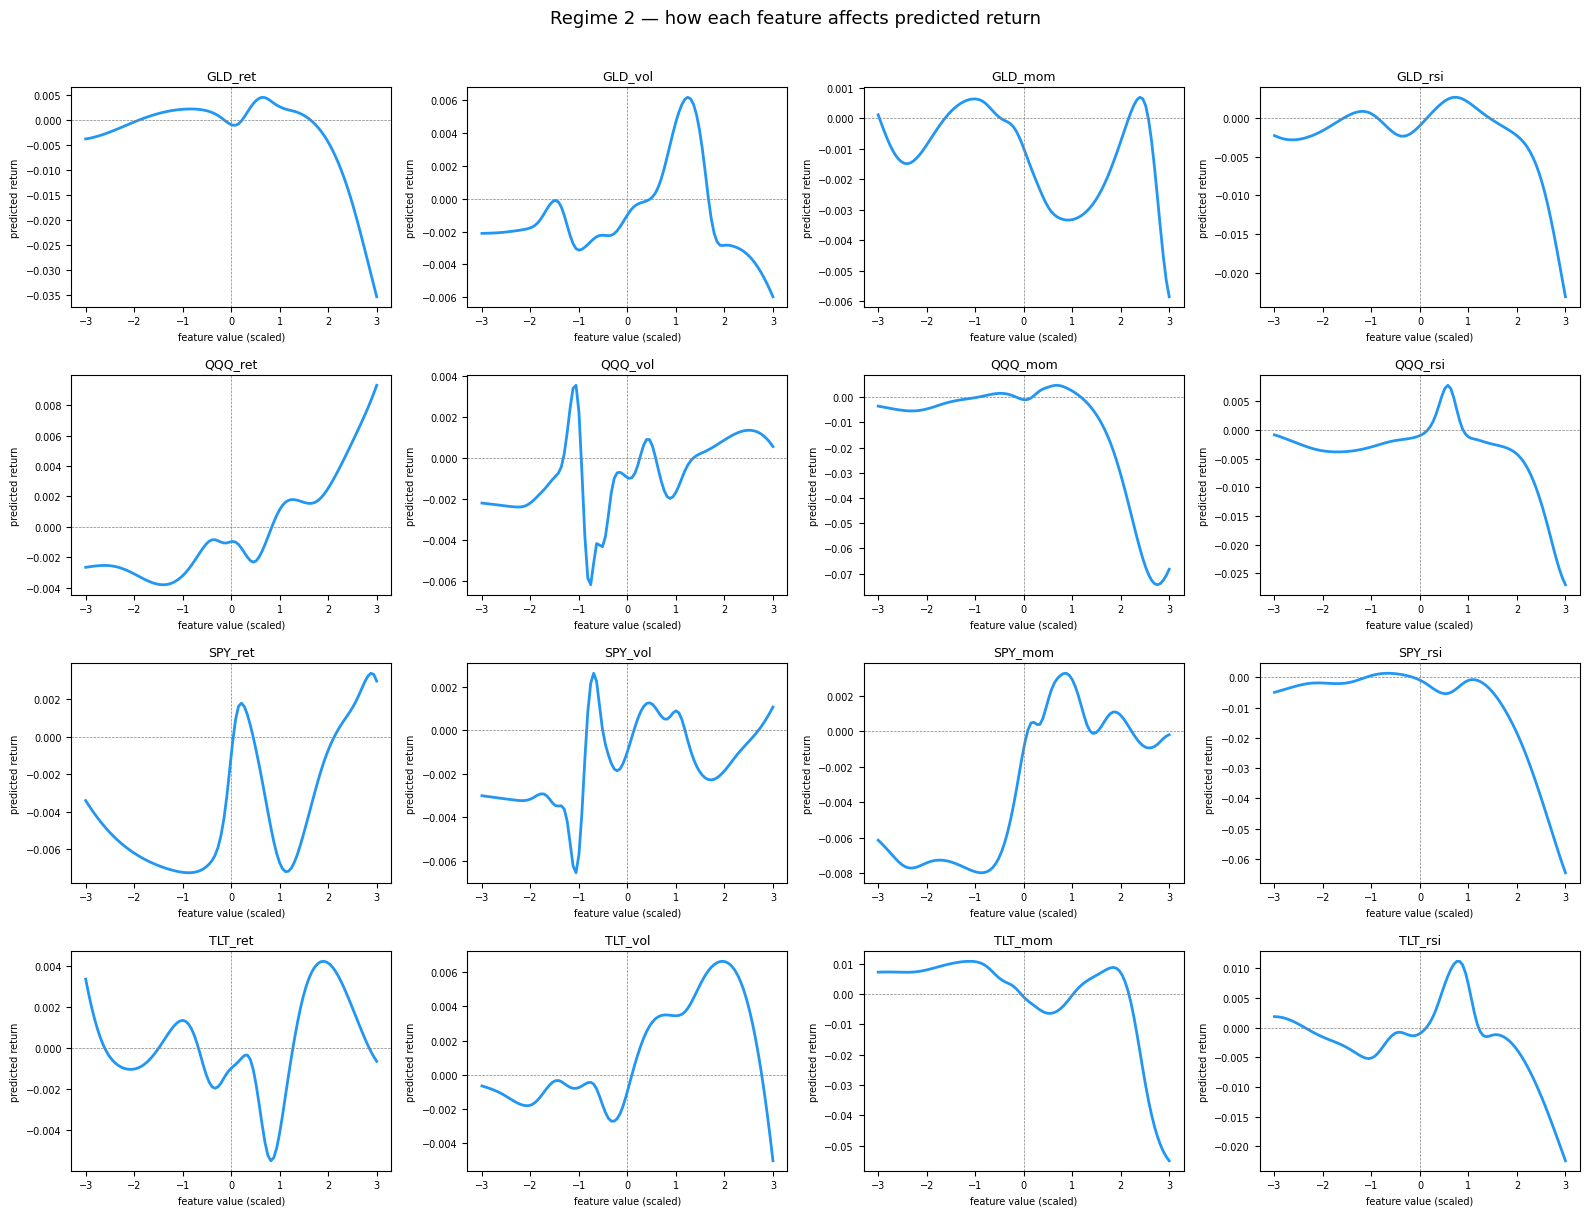

Saved regime 2 plot.


In [35]:
# Cell 6 — manual spline visualization
# Instead of using pykan's buggy built-in plot, we extract the spline
# functions ourselves and plot them directly.
# 
# What we're doing: for each feature, we pass a range of values through
# the trained KAN and record what comes out. The shape of that curve
# is what the model learned about that feature.

feature_names = features.columns.tolist()

for regime in range(N_REGIMES):
    model = kan_models[regime]
    model.eval()
    
    fig, axes = plt.subplots(4, 4, figsize=(16, 12))
    axes = axes.flatten()
    
    for feat_idx in range(input_dim):
        ax = axes[feat_idx]
        
        # Build a test input: vary one feature across its range,
        # hold all others at zero (their mean after scaling)
        test_input = torch.zeros(100, input_dim)
        test_input[:, feat_idx] = torch.linspace(-3, 3, 100)
        
        with torch.no_grad():
            output = model(test_input).squeeze().numpy()
        
        x_vals = torch.linspace(-3, 3, 100).numpy()
        
        ax.plot(x_vals, output, color="#2196F3", linewidth=2)
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.set_title(feature_names[feat_idx], fontsize=9)
        ax.set_xlabel("feature value (scaled)", fontsize=7)
        ax.set_ylabel("predicted return", fontsize=7)
        ax.tick_params(labelsize=7)
    
    # Hide any unused subplot panels
    for idx in range(input_dim, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f"Regime {regime} — how each feature affects predicted return",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f"../outputs/kan_splines_regime_{regime}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved regime {regime} plot.")

In [37]:
# Cell 7 — save KAN models using torch.save
import os
os.makedirs("../models", exist_ok=True)

for regime, model in kan_models.items():
    torch.save(model.state_dict(), f"../models/kan_regime_{regime}.pt")

print("Saved all KAN models.")

Saved all KAN models.
